In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder , StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score,classification_report
import joblib


In [2]:
# pip install xgboost

In [3]:
df=pd.read_csv("diabetes prediction.csv")
df.sample(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
8871,Male,70.00,0.0,0.0,former,25.22,6.0,159.0,1
11239,Female,62.00,0.0,0.0,former,38.33,8.8,159.0,1
1204,Female,41.00,0.0,0.0,No Info,20.90,6.5,85.0,0
3594,Male,1.64,0.0,0.0,never,18.11,4.5,140.0,0
12897,Male,58.00,0.0,0.0,never,33.27,6.2,220.0,1


In [4]:
df.shape

(17000, 9)

In [5]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

| Indicator | Simple Definition | Normal Range | Risk / High Range |
| :--- | :--- | :--- | :--- |
| **Hypertension** | High blood pressure (blood pushing too hard). | Under **120/80** mmHg | **130/80** mmHg or higher |
| **Heart Disease** | Any problem with how the heart works. | No history of heart issues | History of heart conditions |
| **Smoking History** | If you smoke now, used to, or never did. | Never smoked | Current or former smoker |
| **BMI** | A score to see if your weight fits your height. | **18.5 – 24.9** | **30** or higher (Obesity) |
| **HbA1c Level** | Average blood sugar over the last 3 months. | Under **5.7%** | **6.5%** or higher (Diabetes) |
| **Blood Glucose** | The amount of sugar in your blood right now. | **70 – 99** mg/dL (Fasting) | **126** mg/dL or higher (Fasting) |
| **Diabetes** | The diseas | Negative (No Diabetes) | Positive (Confirmed Diabetes) |

In [6]:
df['diabetes'].value_counts()

diabetes
0    8500
1    8500
Name: count, dtype: int64

In [7]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,16960.000000,16951.000000,16922.000000,16940.000000,16949.000000,16967.000000,17000.000000
mean,50.506033,0.151672,0.089469,29.453222,6.169621,163.504568,0.500000
std,21.472463,0.358714,0.285428,7.459203,1.280778,57.025057,0.500015
min,0.080000,0.000000,0.000000,10.980000,3.500000,80.000000,0.000000
25%,36.000000,0.000000,0.000000,25.790000,5.700000,130.000000,0.000000
50%,54.000000,0.000000,0.000000,27.320000,6.100000,155.000000,0.500000
75%,67.000000,0.000000,0.000000,32.860000,6.600000,200.000000,1.000000
max,80.000000,1.000000,1.000000,91.820000,9.000000,300.000000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               16924 non-null  object 
 1   age                  16960 non-null  float64
 2   hypertension         16951 non-null  float64
 3   heart_disease        16922 non-null  float64
 4   smoking_history      16935 non-null  object 
 5   bmi                  16940 non-null  float64
 6   HbA1c_level          16949 non-null  float64
 7   blood_glucose_level  16967 non-null  float64
 8   diabetes             17000 non-null  int64  
dtypes: float64(6), int64(1), object(2)
memory usage: 1.2+ MB


# ***Handle duplicates & Missing Values***

In [9]:
df.duplicated().sum()

66

In [10]:
df.drop_duplicates(ignore_index=True, inplace=True)

In [11]:
df.duplicated().sum()

0

In [12]:
df.isna().sum()

gender                 60
age                    24
hypertension           33
heart_disease          62
smoking_history        49
bmi                    44
HbA1c_level            35
blood_glucose_level    17
diabetes                0
dtype: int64

In [13]:
cleaned_data=(df.shape[0])-(df.isna().sum().sum())
cleaned_data

16610

In [14]:
df.dropna(inplace=True)
df.reset_index(inplace=True,drop=True)

In [15]:
df.isna().sum().sum(), df.shape[0]

(0, 16818)

In [16]:
for col in df.select_dtypes('object'):
    print(col,df[col].unique())
    print("_"*30)

gender ['Male' 'Female' 'Other']
______________________________
smoking_history ['never' 'No Info' 'former' 'current' 'not current' 'ever']
______________________________


In [17]:
df['gender'].replace('Other',np.nan,inplace=True)
df['smoking_history'].replace('No Info',np.nan,inplace=True)
df.isna().sum()

C:\Users\original\AppData\Local\Temp\ipykernel_14888\3104539559.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace('Other',np.nan,inplace=True)
C:\Users\original\AppData\Local\Temp\ipykernel_14888\3104539559.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



gender                    2
age                       0
hypertension              0
heart_disease             0
smoking_history        4532
bmi                       0
HbA1c_level               0
blood_glucose_level       0
diabetes                  0
dtype: int64

In [18]:
df.dropna(subset='gender',axis=0,inplace=True)
df.reset_index(inplace=True,drop=True)

In [19]:
imputer=SimpleImputer(missing_values=np.nan,strategy="most_frequent") 

df[["smoking_history"]]=imputer.fit_transform(df[["smoking_history"]])
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Male,22.0,0.0,0.0,never,36.29,6.1,100.0,0
1,Female,29.0,0.0,0.0,never,27.32,4.0,140.0,0
2,Female,4.0,0.0,0.0,never,13.29,6.0,85.0,0
3,Male,28.0,0.0,0.0,former,31.58,4.8,130.0,0
4,Female,62.0,0.0,0.0,current,27.32,3.5,159.0,0
...,...,...,...,...,...,...,...,...,...
16811,Male,63.0,1.0,0.0,never,27.32,6.1,260.0,1
16812,Female,68.0,0.0,0.0,ever,38.23,6.5,220.0,1
16813,Male,47.0,0.0,0.0,ever,40.67,6.0,220.0,1
16814,Female,71.0,0.0,0.0,never,29.39,8.2,240.0,1


# ***Visualization***

In [20]:
for col in df.columns:
    if(df[col].nunique()==2):
        print(col,df[col].unique())

gender ['Male' 'Female']
hypertension [0. 1.]
heart_disease [0. 1.]
diabetes [0 1]


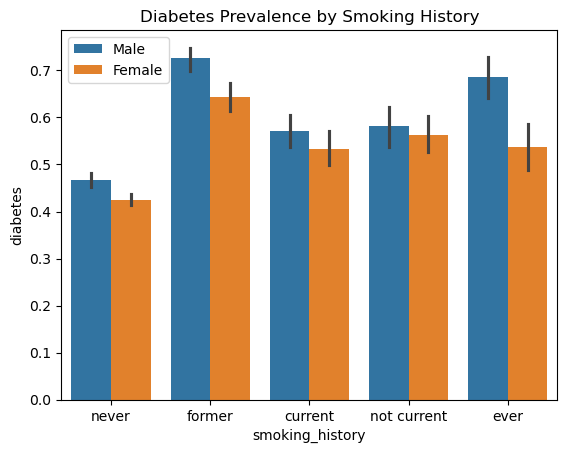

In [21]:
sns.barplot(x='smoking_history', y='diabetes',hue='gender', data=df)
plt.title('Diabetes Prevalence by Smoking History')
plt.legend(loc='upper left')
plt.show()

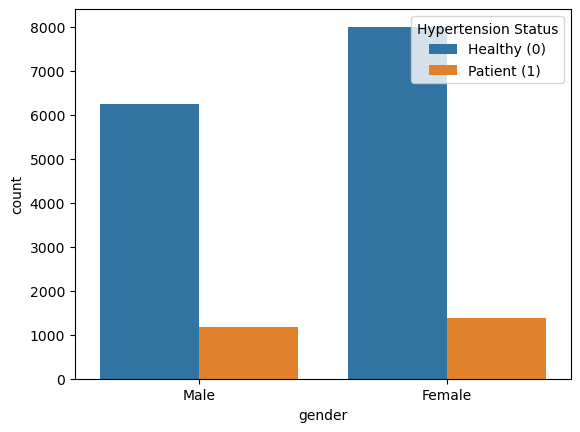

In [22]:
sns.countplot(x='gender',hue='hypertension',data=df)
plt.legend(title='Hypertension Status', labels=['Healthy (0)', 'Patient (1)'],loc='upper right')

plt.show()

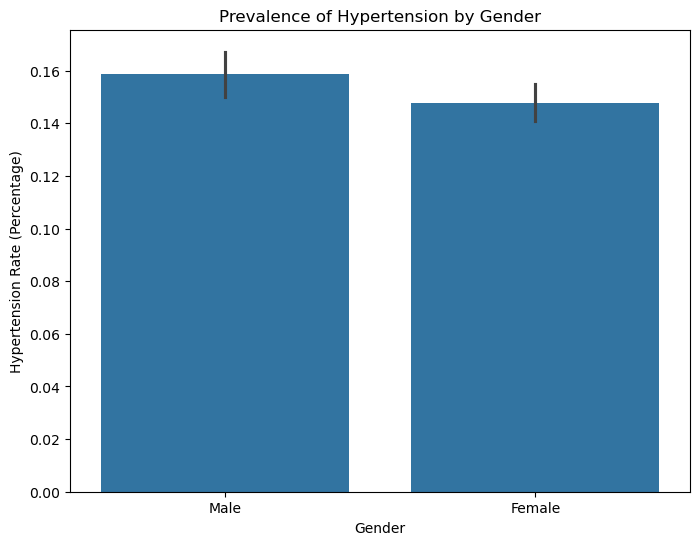

In [23]:
plt.figure(figsize=(8, 6))
sns.barplot(x='gender', y='hypertension', data=df)

plt.title('Prevalence of Hypertension by Gender')
plt.ylabel('Hypertension Rate (Percentage)')
plt.xlabel('Gender')

plt.show()

### 📊 Comparison: CountPlot vs. BarPlot

| Plot Type | What it shows | Best used for... |
| :--- | :--- | :--- |
| **CountPlot** | Shows the **total number** of people in each category. | Knowing the **sample size** (e.g., How many males vs. females are in our data). |
| **BarPlot** | Shows the **average/percentage** of a value (like Hypertension). | Finding the **risk level** (e.g., Which gender is more likely to have high blood pressure). |

**In short:**
* **CountPlot** answers: *"How many?"*
* **BarPlot** answers: *"What is the percentage?"*

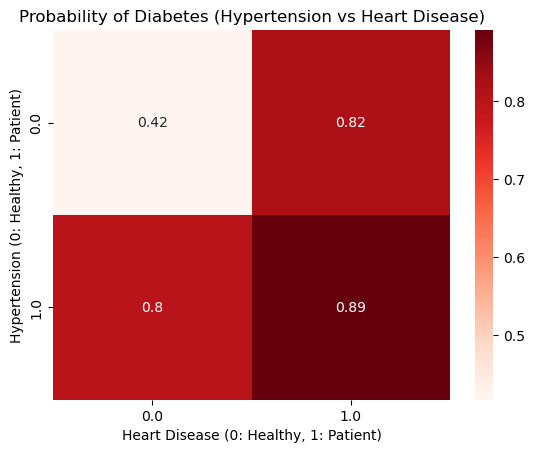

In [24]:
pivot_table = df.pivot_table(index='hypertension', columns='heart_disease', values='diabetes', aggfunc='mean')

sns.heatmap(pivot_table, annot=True, cmap='Reds')
plt.title('Probability of Diabetes (Hypertension vs Heart Disease)')
plt.xlabel('Heart Disease (0: Healthy, 1: Patient)')
plt.ylabel('Hypertension (0: Healthy, 1: Patient)')

plt.show()

C:\Users\original\AppData\Local\Temp\ipykernel_14888\119973238.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='hypertension', y='diabetes', hue='smoking_history', data=df, ci=None)


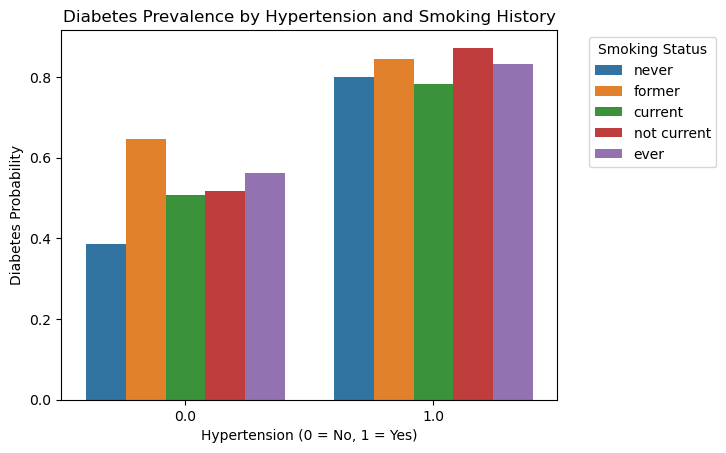

In [25]:
sns.barplot(x='hypertension', y='diabetes', hue='smoking_history', data=df, ci=None)

plt.title('Diabetes Prevalence by Hypertension and Smoking History')
plt.ylabel('Diabetes Probability')
plt.xlabel('Hypertension (0 = No, 1 = Yes)')

plt.legend(title='Smoking Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

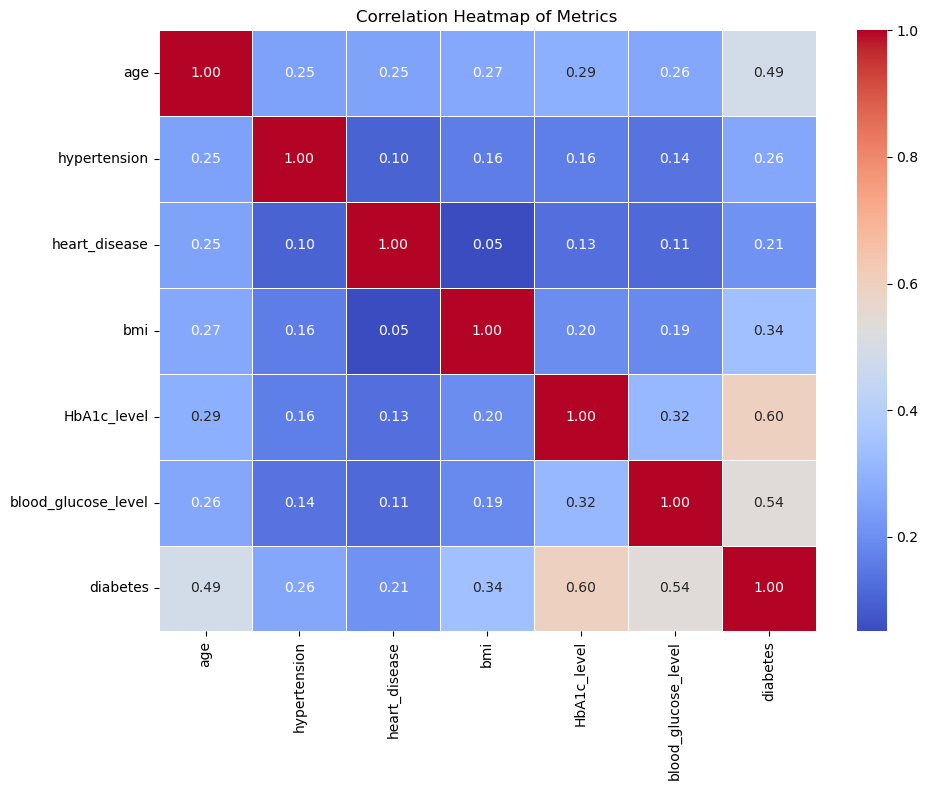

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Metrics')
plt.tight_layout()
plt.show()

# ***Feature Engineering***

In [27]:
X=df.drop('diabetes',axis=1)
y=df['diabetes']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [29]:
categorical_cols = ['gender', 'smoking_history']
numerical_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

In [30]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

In [31]:
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# ***Modeling***

In [32]:
lg=LogisticRegression()
lg.fit(X_train,y_train)
y_train_pred=lg.predict(X_train)
y_test_pred=lg.predict(X_test)

In [33]:
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)*100:.2f}%")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred)*100:.2f}%")

print("\n" + "="*30)
print("TEST DATA REPORT")
print("="*30)
print(classification_report(y_test, y_test_pred))

Training Accuracy: 88.48%
Testing Accuracy: 88.64%

TEST DATA REPORT
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      1673
           1       0.88      0.89      0.89      1691

    accuracy                           0.89      3364
   macro avg       0.89      0.89      0.89      3364
weighted avg       0.89      0.89      0.89      3364



In [34]:
models={
    "RandomForestClassifier":RandomForestClassifier(random_state=42, n_estimators=20,criterion='entropy',max_depth=10),
    "XGBoost":XGBClassifier(n_estimators=20,learning_rate=0.1,use_label_encoder=False,eval_metric='logloss',random_state=42)
}

In [35]:
accuracy=[]
for model_name , model in models.items():
    model.fit(X_train,y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    Acc_Train = accuracy_score(y_train,y_pred_train)
    Acc_Test  =  accuracy_score(y_test,y_pred_test)


    Pre_Train = precision_score(y_train,y_pred_train,average='binary') 
    Pre_Test  =  precision_score(y_test,y_pred_test,average='binary')

    Rec_Train = recall_score(y_train,y_pred_train,average='binary')
    Rec_Test  =  recall_score(y_test,y_pred_test,average='binary')

    F1_Train = f1_score(y_train,y_pred_train,average='binary')
    F1_Test  =  f1_score(y_test,y_pred_test,average='binary')

    accuracy.append([Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test])

d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:50:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
pd.DataFrame(accuracy,columns=["Acc_Train","Pre_Train","Rec_Train","F1_Train",
                               "Acc_Test","Pre_Test","Rec_Test","F1_Test"],index=models.keys())

,Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test
RandomForestClassifier,0.913842,0.923331,0.904432,0.913784,0.910226,0.912656,0.908338,0.910492
XGBoost,0.904326,0.875034,0.945516,0.908911,0.902794,0.869048,0.949734,0.907601


In [37]:
import pickle
Final_Model=XGBClassifier(n_estimators=20,learning_rate=0.1,use_label_encoder=False,eval_metric='logloss',random_state=42)
Final_Model.fit(X_train,y_train)



d:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:50:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=20, n_jobs=None,
              num_parallel_tree=None, ...)

# ***Deployment***

In [39]:
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(Final_Model, 'model.pkl')

['model.pkl']